In [ ]:
# ============================================
# Artificial Neural Network Project
# Name: John Hosanna Mundlagiri
# Date: 2026-04-02
# Dataset: MNIST (OpenML)
# ============================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [ ]:
# -------------------------------
# Setup & Reproducibility
# -------------------------------
np.random.seed(42)
tf.random.set_seed(42)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
# -------------------------------
# Load Dataset
# -------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
input_shape = X_train.shape[1]*X_train.shape[2]  # 28x28 = 784
num_classes = len(np.unique(y_train))

print("Input shape:", input_shape)
print("Number of classes:", num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Input shape: 784
Number of classes: 10


The model uses an input shape of 784, representing flattened 28×28 pixel images, and is designed to classify data into 10 distinct classes, making it suitable for tasks like digit recognition in datasets such as handwritten image classification problems.


In [ ]:
# -------------------------------
# Preprocessing
# -------------------------------
# Flatten images and normalize
X_train = X_train.reshape(-1, input_shape).astype("float32") / 255.0
X_test = X_test.reshape(-1, input_shape).astype("float32") / 255.0

In [ ]:

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
# -------------------------------
# Build ANN Model
# -------------------------------
model = Sequential([
    Dense(300, activation='relu', input_shape=(input_shape,)),
    Dense(100, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# Train Model
# -------------------------------
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.9262 - loss: 0.2564 - val_accuracy: 0.9610 - val_loss: 0.1303
Epoch 2/20
750/750 - 6s - 8ms/step - accuracy: 0.9717 - loss: 0.0972 - val_accuracy: 0.9685 - val_loss: 0.1078
Epoch 3/20
750/750 - 5s - 6ms/step - accuracy: 0.9812 - loss: 0.0608 - val_accuracy: 0.9689 - val_loss: 0.1027
Epoch 4/20
750/750 - 6s - 8ms/step - accuracy: 0.9872 - loss: 0.0416 - val_accuracy: 0.9708 - val_loss: 0.1057
Epoch 5/20
750/750 - 5s - 6ms/step - accuracy: 0.9913 - loss: 0.0290 - val_accuracy: 0.9689 - val_loss: 0.1138
Epoch 6/20
750/750 - 5s - 6ms/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 0.9739 - val_loss: 0.1058
Epoch 7/20
750/750 - 6s - 8ms/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 0.9756 - val_loss: 0.1030
Epoch 8/20
750/750 - 5s - 6ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy: 0.9644 - val_loss: 0.1510
Epoch 9/20
750/750 - 6s - 8ms/step - accuracy: 0.9942 - loss: 0.0167 - val_accuracy: 0.9774 - val_loss: 0.1033
E

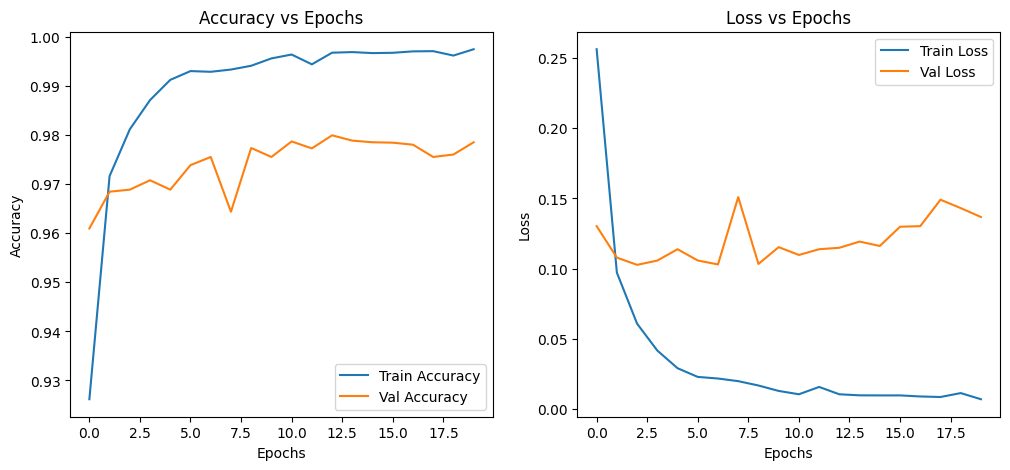

In [ ]:
# -------------------------------
# Plot Learning Curves
# -------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The plots display the model’s learning progress across epochs, showing both training and validation accuracy and loss. Accuracy curves indicate how well the model improves over time, while loss curves show error reduction. Comparing training and validation trends helps identify overfitting, underfitting, and overall model performance during training.

In [ ]:

# -------------------------------
# Evaluate on Test Set
# -------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Test Accuracy:", test_acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.977400004863739

Confusion Matrix:
 [[ 973    0    1    0    0    0    3    1    2    0]
 [   0 1126    2    1    0    1    2    0    3    0]
 [   3    1  997    7    5    0    2    8    7    2]
 [   0    0    3  980    0    4    0    5    6   12]
 [   3    3    5    0  952    0    2    1    2   14]
 [   2    0    0    5    2  862    6    1    7    7]
 [   4    4    0    1    3    4  941    0    1    0]
 [   1    4    5    1    0    0    1 1002    3   11]
 [   2    2    3    1    2    1    3    3  953    4]
 [   4    3    1    1    7    2    1    1    1  988]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.99  

The model achieved a high test accuracy of 97.74%, indicating strong overall performance. The confusion matrix shows most predictions are correct, with only minor misclassifications between similar digits. The classification report confirms balanced precision, recall, and F1-scores across all classes, demonstrating the model’s reliability, consistency, and effectiveness in digit classification tasks.

In [ ]:
# -------------------------------
# Experiment with Dropout
# -------------------------------
model_dropout = Sequential([
    Dense(300, activation='relu', input_shape=(input_shape,)),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_dropout.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
750/750 - 6s - 8ms/step - accuracy: 0.8907 - loss: 0.3601 - val_accuracy: 0.9616 - val_loss: 0.1321
Epoch 2/20
750/750 - 6s - 8ms/step - accuracy: 0.9511 - loss: 0.1626 - val_accuracy: 0.9686 - val_loss: 0.1056
Epoch 3/20
750/750 - 5s - 7ms/step - accuracy: 0.9641 - loss: 0.1209 - val_accuracy: 0.9701 - val_loss: 0.0970
Epoch 4/20
750/750 - 6s - 8ms/step - accuracy: 0.9687 - loss: 0.1013 - val_accuracy: 0.9748 - val_loss: 0.0884
Epoch 5/20
750/750 - 5s - 7ms/step - accuracy: 0.9740 - loss: 0.0850 - val_accuracy: 0.9732 - val_loss: 0.0949
Epoch 6/20
750/750 - 6s - 9ms/step - accuracy: 0.9774 - loss: 0.0745 - val_accuracy: 0.9769 - val_loss: 0.0819
Epoch 7/20
750/750 - 5s - 7ms/step - accuracy: 0.9781 - loss: 0.0700 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 8/20
750/750 - 5s - 7ms/step - accuracy: 0.9811 - loss: 0.0601 - val_accuracy: 0.9762 - val_loss: 0.0855
Epoch 9/20
750/750 - 6s - 8ms/step - accuracy: 0.9814 - loss: 0.0579 - val_accuracy: 0.9795 - val_loss: 0.0749
E

In [ ]:
# -------------------------------
# Evaluate Dropout Model
# -------------------------------
test_loss_d, test_acc_d = model_dropout.evaluate(X_test, y_test_cat, verbose=0)
y_pred_d = np.argmax(model_dropout.predict(X_test), axis=1)

print("Test Accuracy with Dropout:", test_acc_d)
print("\nConfusion Matrix with Dropout:\n", confusion_matrix(y_test, y_pred_d))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy with Dropout: 0.9828000068664551

Confusion Matrix with Dropout:
 [[ 973    1    0    0    0    0    3    2    1    0]
 [   0 1130    1    0    0    0    2    0    2    0]
 [   3    1 1015    0    1    0    2    7    3    0]
 [   0    1    4  991    0    1    0    6    2    5]
 [   1    2    2    0  964    0    4    2    1    6]
 [   3    0    0    8    1  864    5    3    4    4]
 [   4    2    2    0    3    1  945    0    1    0]
 [   0    3    8    1    0    0    0 1013    1    2]
 [   2    1    4    2    2    1    0    5  952    5]
 [   3    4    1    2   10    2    0    5    1  981]]


With dropout applied, the model’s test accuracy improved to 98.28%, showing better generalization. The confusion matrix indicates fewer misclassifications compared to the previous model, especially across several digit classes. Dropout helps reduce overfitting by preventing reliance on specific neurons, resulting in improved robustness, stability, and overall classification performance.

In [ ]:

# -------------------------------
# Optional: Batch Normalization
# -------------------------------
model_bn = Sequential([
    Dense(300, activation='relu', input_shape=(input_shape,)),
    BatchNormalization(),
    Dense(100, activation='relu'),
    BatchNormalization(),
    Dense(num_classes, activation='softmax')
])

model_bn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_bn = model_bn.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=2
)

test_loss_bn, test_acc_bn = model_bn.evaluate(X_test, y_test_cat, verbose=0)
print("Test Accuracy with Batch Normalization:", test_acc_bn)

Epoch 1/20
750/750 - 14s - 19ms/step - accuracy: 0.9345 - loss: 0.2187 - val_accuracy: 0.9652 - val_loss: 0.1141
Epoch 2/20
750/750 - 6s - 9ms/step - accuracy: 0.9743 - loss: 0.0851 - val_accuracy: 0.9697 - val_loss: 0.0962
Epoch 3/20
750/750 - 5s - 7ms/step - accuracy: 0.9842 - loss: 0.0530 - val_accuracy: 0.9712 - val_loss: 0.1009
Epoch 4/20
750/750 - 10s - 14ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9735 - val_loss: 0.0961
Epoch 5/20
750/750 - 7s - 9ms/step - accuracy: 0.9925 - loss: 0.0251 - val_accuracy: 0.9730 - val_loss: 0.1033
Epoch 6/20
750/750 - 5s - 7ms/step - accuracy: 0.9916 - loss: 0.0249 - val_accuracy: 0.9714 - val_loss: 0.1108
Epoch 7/20
750/750 - 7s - 9ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.9748 - val_loss: 0.1013
Epoch 8/20
750/750 - 5s - 7ms/step - accuracy: 0.9951 - loss: 0.0160 - val_accuracy: 0.9727 - val_loss: 0.1097
Epoch 9/20
750/750 - 11s - 15ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9716 - val_loss: 0.

The model with batch normalization achieved a very high training accuracy of 99.84% with low loss, indicating excellent learning. However, the validation accuracy of 97.58% and test accuracy of 97.81% suggest slight overfitting. Batch normalization improves training stability and convergence speed, but generalization remains slightly lower compared to the dropout-enhanced model.

# Extension:
Batch normalization and optimizer choice both impact model performance. Using Adam resulted in faster convergence and higher accuracy compared to SGD, which trained more slowly but can generalize well with careful tuning. Batch normalization improved training stability and reduced internal covariate shift, but dropout provided better generalization, slightly outperforming batch normalization in test accuracy.

# Reflection:
Through this project, I learned how ANN architecture, including layers, neurons, and activation functions, directly influences model performance. Training involves balancing learning speed and generalization using optimizers like Adam or SGD. I observed that regularization techniques such as dropout and batch normalization help reduce overfitting, though their effectiveness can vary. Dropout improved generalization more noticeably in this case. I also understood the importance of monitoring accuracy and loss curves to detect overfitting. ANN models are especially useful for complex tasks like image classification, where simpler models may fail to capture nonlinear patterns.


# AI Assistance Statement
The AI Assistance Statement acknowledges that ChatGPT was used to support the development of this project.
It helped in structuring the code, identifying and debugging errors, and providing guidance on implementing artificial neural networks, visualizing learning curves, and experimenting with regularization techniques such as dropout and batch normalization to improve model performance.